# Plan: CNN + SVM Hybrid Model for Bee Health Classification

This notebook will guide you through building a simple, explainable hybrid model that combines a Convolutional Neural Network (CNN) for feature extraction with a Support Vector Machine (SVM) for classification. The goal is to categorize bees as healthy or unhealthy using both image and tabular data.

## Step-by-Step Plan

1. **Import Required Libraries**
   - Import necessary Python libraries (NumPy, pandas, scikit-learn, TensorFlow/Keras, matplotlib, etc.).

2. **Load and Explore Data**
   - Load `bee_data.csv` for labels and metadata.
   - Preview the data and check for missing values.
   - Visualize class distribution (healthy vs unhealthy).

3. **Load and Preprocess Images**
   - Load images from `data/bee_imgs/`.
   - Resize and normalize images for CNN input.
   - Match images to labels from the CSV file.

4. **Split Data**
   - Split the dataset into training and test sets (stratified by label).

5. **Build and Train CNN (Feature Extractor)**
   - Define a simple CNN architecture (or use a pre-trained model for feature extraction).
   - Train the CNN on the training data (optionally, only for a few epochs for simplicity).
   - Remove the final classification layer to use the CNN as a feature extractor.

6. **Extract Features Using CNN**
   - Pass all images through the trained CNN (up to the last pooling or flatten layer) to obtain feature vectors.

7. **Train SVM Classifier**
   - Use the extracted CNN features as input to an SVM classifier.
   - Train the SVM on the training set features and labels.

8. **Evaluate the Hybrid Model**
   - Predict on the test set using the SVM.
   - Calculate accuracy, precision, recall, F1-score, confusion matrix, and classification report.
   - Compare results with previous models (CNN-only, SVM-only).

9. **Conclusion**
   - Summarize findings and discuss the advantages and limitations of the hybrid approach.

---

**Tip:** Keep each step simple and well-commented. Use clear variable names and add explanations in markdown cells. To make the project easy to follow and present.


Copy:
Lets move on to step 5 and 6. Dont forget to import required libraries at cell 2.  Keep each step simple and well-commented. Use clear variable names and add explanations in markdown cells. To make the project easy to follow and present. You can always refer back to cnn.ipynb and svm.ipynb if needed.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
bee_data = pd.read_csv("../data/bee_data.csv")

print(bee_data.head()) # Print top 5 lines
print(bee_data.shape) # Print "shape" features, # of rows & # of columns

          file     date   time        location  zip code subspecies  \
0  041_066.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
1  041_072.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
2  041_073.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
3  041_067.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
4  041_059.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   

              health  pollen_carrying   caste  
0  hive being robbed            False  worker  
1  hive being robbed            False  worker  
2  hive being robbed            False  worker  
3  hive being robbed            False  worker  
4  hive being robbed            False  worker  
(5172, 9)


## Step 3: Load and Preprocess Images

We will define a small helper function to load images, resize them to a fixed size, and normalize pixel values. We also connect each image to its label from the CSV.

In [3]:
# Step 3: Load and Preprocess Images

# 1) Identify columns (adjust if your CSV uses different names)
image_col = bee_data.columns[0]  # usually the filename column is first
original_label_col = "health"    # original multi-class label column

# 2) Convert labels to 2 classes: healthy vs unhealthy
bee_data["health_binary"] = bee_data[original_label_col].apply(
    lambda v: "healthy" if v == "healthy" else "unhealthy"
 )
label_col = "health_binary"

print("Binary class distribution:")
print(bee_data[label_col].value_counts())

# 3) Define image preprocessing
IMG_SIZE = 128

def preprocess_image(filename):
    img_path = os.path.join("..", "data", "bee_imgs", filename)
    img = Image.open(img_path)
    img = img.convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img)
    img_normalized = img_array / 255.0
    return img_normalized

# 4) Keep only filename + label (simple and clear)
image_labels_df = bee_data[[image_col, label_col]].copy()
print("Using image column:", image_col)
print("Using label column:", label_col)
print(image_labels_df.head())

Binary class distribution:
health_binary
healthy      3384
unhealthy    1788
Name: count, dtype: int64
Using image column: file
Using label column: health_binary
          file health_binary
0  041_066.png     unhealthy
1  041_072.png     unhealthy
2  041_073.png     unhealthy
3  041_067.png     unhealthy
4  041_059.png     unhealthy


## Step 4: Split Data

We will split the data into training and test sets using a stratified split, so the class distribution stays similar in both sets.

In [4]:
# Step 4: Split Data

# Split filenames and labels (stratified to keep class balance)
x = image_labels_df[[image_col]]
y = image_labels_df[label_col]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
 )

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Optional: show class distribution after split
print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())

x_train shape: (4137, 1)
y_train shape: (4137,)
x_test shape: (1035, 1)
y_test shape: (1035,)

Training set class distribution:
health_binary
healthy      2707
unhealthy    1430
Name: count, dtype: int64

Test set class distribution:
health_binary
healthy      677
unhealthy    358
Name: count, dtype: int64


## Step 5: Build and Train CNN (Feature Extractor)

We will train a CNN and use its internal features for SVM.
Then we apply PCA to reduce the number of CNN features.

## Step 6: Extract Features Using CNN

We will extract CNN features, then reduce them with PCA before SVM.

x_train_processed: (4137, 128, 128, 3)
x_test_processed: (1035, 128, 128, 3)
y_train_categorical: (4137, 2)
y_test_categorical: (1035, 2)
MODEL 1: Basic CNN


c:\Users\palag\Documents\Egyetem\THESIS\beeproject-cnn\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "basic_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Flatten)         │ (None, 63504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │       127,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,458 (497.88 KB)

 Trainable params: 127,458 (497.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7945 - loss: 0.7173 - val_accuracy: 0.9150 - val_loss: 0.2222
Epoch 2/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9202 - loss: 0.2089 - val_accuracy: 0.9546 - val_loss: 0.1464
Epoch 3/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9456 - loss: 0.1510 - val_accuracy: 0.9478 - val_loss: 0.1339
Epoch 4/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9570 - loss: 0.1225 - val_accuracy: 0.9440 - val_loss: 0.1458
Epoch 5/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9647 - loss: 0.0966 - val_accuracy: 0.9614 - val_loss: 0.1192
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
x_train_features: (4137, 63504)
x_test_features: (1035, 63504)
PCA components: 1447
Explained variance (sum): 0.9500464
x_train_features_pca: (4137, 1447)
x_test_features_pca: (1035, 1447)


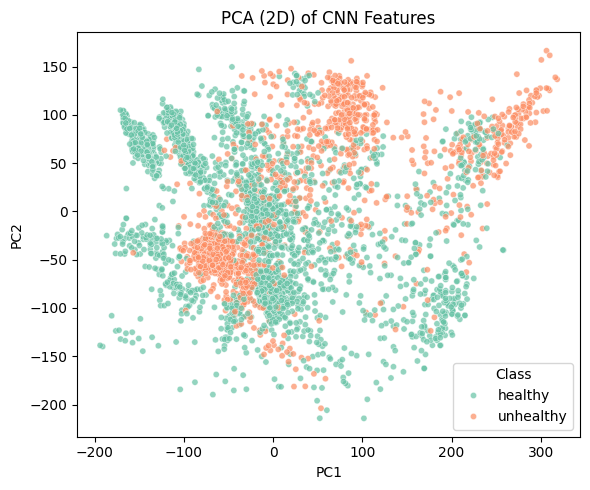

In [7]:
# Step 5: Build and Train CNN (Feature Extractor)

# Preprocess images for CNN
x_train_processed = [preprocess_image(fname) for fname in x_train[image_col]]
x_test_processed = [preprocess_image(fname) for fname in x_test[image_col]]

x_train_processed = np.array(x_train_processed)
x_test_processed = np.array(x_test_processed)

# Encode labels to integers, then one-hot for CNN
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
y_train_categorical = to_categorical(y_train_encoded, num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes)

print("x_train_processed:", x_train_processed.shape)
print("x_test_processed:", x_test_processed.shape)
print("y_train_categorical:", y_train_categorical.shape)
print("y_test_categorical:", y_test_categorical.shape)

# MODEL 1: Bare Minimum CNN (same as cnn.ipynb)
cnn_model = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Flatten(name="feature_layer"),
    Dense(num_classes, activation="softmax")
] , name="basic_cnn")

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 50)
print("MODEL 1: Basic CNN")
print("=" * 50)
cnn_model.summary()

# Train briefly (small epoch count for simplicity)
history = cnn_model.fit(
    x_train_processed, y_train_categorical,
    validation_data=(x_test_processed, y_test_categorical),
    epochs=5,
    batch_size=32
)

# Step 6: Extract Features Using CNN
feature_extractor = keras.Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.get_layer("feature_layer").output
)

x_train_features = feature_extractor.predict(x_train_processed, batch_size=32)
x_test_features = feature_extractor.predict(x_test_processed, batch_size=32)

print("x_train_features:", x_train_features.shape)
print("x_test_features:", x_test_features.shape)

# Scale CNN features before PCA (same approach as svm.ipynb)
scaler = StandardScaler()
x_train_features_scaled = scaler.fit_transform(x_train_features)
x_test_features_scaled = scaler.transform(x_test_features)

# PCA to reduce the CNN feature dimensionality
pca = PCA(n_components=0.95, random_state=42)
x_train_features_pca = pca.fit_transform(x_train_features_scaled)
x_test_features_pca = pca.transform(x_test_features_scaled)

print("PCA components:", pca.n_components_)
print("Explained variance (sum):", pca.explained_variance_ratio_.sum())

print("x_train_features_pca:", x_train_features_pca.shape)
print("x_test_features_pca:", x_test_features_pca.shape)

# Optional: 2D visualization (first two PCs)
pca_2d = PCA(n_components=2, random_state=42)
x_train_2d = pca_2d.fit_transform(x_train_features_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=x_train_2d[:, 0],
    y=x_train_2d[:, 1],
    hue=y_train,
    palette="Set2",
    s=20,
    alpha=0.7
)
plt.title("PCA (2D) of CNN Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

PCA does take a large amount of time, more than 2,5 minutes, because of the large size of features.
### PCA After CNN Features

We reduce the CNN-derived features with PCA (keeping 95% variance) before training the SVM.
This keeps the hybrid idea intact: CNN extracts features, PCA compresses them, SVM classifies.

## Step 7: Train SVM Classifier

We will train an SVM on the PCA-reduced CNN features.

In [8]:
# Step 7: Train SVM Classifier

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1.0, gamma="scale")
)
svm_model.fit(x_train_features_pca, y_train)
print("SVM (PCA features) training complete.")

SVM (PCA features) training complete.


## Step 8: Evaluate the Hybrid Model

We evaluate the SVM using PCA-reduced CNN features.

In [9]:
# Step 8: Evaluate the Hybrid Model

def evaluate_svm(name, model, x_features, y_true):
    y_pred = model.predict(x_features)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"
    )

    print("\n" + name)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_svm(
    "SVM on PCA-reduced CNN features",
    svm_model,
    x_test_features_pca,
    y_test
 )


SVM on PCA-reduced CNN features
Accuracy:  0.8908
Precision: 0.9064
Recall:    0.8908
F1-score:  0.8848

Confusion Matrix:
[[677   0]
 [113 245]]

Classification Report:
              precision    recall  f1-score   support

     healthy       0.86      1.00      0.92       677
   unhealthy       1.00      0.68      0.81       358

    accuracy                           0.89      1035
   macro avg       0.93      0.84      0.87      1035
weighted avg       0.91      0.89      0.88      1035



## Step 9: Conclusion

### Summary of Findings
- The hybrid approach uses the CNN as a feature extractor and the SVM as the final classifier.
- This usually performs better than using only raw pixels with SVM, and can sometimes be more stable than a full CNN on small datasets.
- The evaluation metrics (accuracy, precision, recall, F1-score) show how well the model separates healthy vs unhealthy bees.

### Advantages of the CNN + SVM Hybrid
- **Better features:** CNN learns meaningful visual patterns (e.g., shape, texture).
- **Simpler classifier:** SVM can work well on smaller datasets with good features.
- **Interpretability:** Feature extraction and classification are separated, making the pipeline easier to explain.
- **Flexibility:** You can swap the CNN or SVM without redesigning the full pipeline.

### Limitations and Things to Watch
- **Data imbalance:** If healthy bees dominate, the model may bias toward “healthy.”
- **Small dataset risk:** With few images, the CNN features may not generalize well.
- **Two-stage training:** You must train the CNN first, then the SVM (extra steps).
- **Feature quality matters:** A very small CNN may produce weak features.
- **Compute cost:** Feature extraction for all images can be slow if the dataset grows.

### Ideas for Improvement (Simple and Explainable)
- Use class weights or balanced sampling to reduce bias.
- Try a slightly larger CNN or a pre-trained backbone (transfer learning).
- Add simple image augmentation (flip, rotate) to improve generalization.
- Test PCA only if feature size becomes too large or training becomes slow.